# News Article Summarization: TextRank vs. BART vs. Fine-tuned T5

This project compares three approaches for summarizing news articles:

- **TextRank**: extractive baseline that selects the most central sentences
- **BART** (`facebook/bart-large-cnn`): pretrained abstractive model
- **T5-small**: abstractive model fine-tuned on the news dataset

**Dataset:** News Summary (Kaggle), news articles paired with short human-written summaries.

**Metric:** ROUGE-1, ROUGE-2 and ROUGE-L on a held-out test set.

**Stack:** Python, PyTorch, Hugging Face Transformers, Gradio.

## 1. Environment setup

Check that a GPU is available. Training and generation are much faster on a GPU.

In [1]:
import torch
print('GPU available?', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name:', torch.cuda.get_device_name(0))
else:
    print('No GPU found! Go to Runtime -> Change runtime type -> select T4 GPU.')

GPU available? True
GPU name: Tesla T4


### Dependencies

Install the required libraries.

In [2]:
!pip install -q transformers datasets evaluate rouge_score accelerate sentencepiece gradio nltk networkx scikit-learn
print('Installation finished!')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.0 MB/s eta 0:00:00
Installation finished!


## 2. Data

The dataset is the News Summary dataset from Kaggle (`news_summary.csv`). Upload the file when prompted.

In [3]:
from google.colab import files
uploaded = files.upload()
print('Uploaded files:', list(uploaded.keys()))

Saving news_summary.csv to news_summary.csv
Uploaded files: ['news_summary.csv']


### 2.1 Cleaning and train/test split

- Keep the article (`ctext`) and summary (`text`) columns, then drop missing values and duplicates
- Shuffle with a fixed seed (`random_state=42`) for reproducibility
- Use 2,000 articles for training and 100 articles for testing

A subset is used because of limited time and compute.

In [4]:
import pandas as pd

df = pd.read_csv('news_summary.csv', encoding='latin-1')
print('Columns:', df.columns.tolist())

df = df[['ctext', 'text']].dropna().drop_duplicates()
df = df.rename(columns={'ctext': 'article', 'text': 'summary'})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print('Total rows:', len(df))

train_df = df.iloc[:2000].reset_index(drop=True)
test_df = df.iloc[2000:2100].reset_index(drop=True)
print('Train rows:', len(train_df), '| Test rows:', len(test_df))

print('\n--- ARTICLE (first 600 characters) ---')
print(test_df.article[0][:600])
print('\n--- HUMAN SUMMARY ---')
print(test_df.summary[0])

Columns: ['author', 'date', 'headlines', 'read_more', 'text', 'ctext']
Total rows: 4396
Train rows: 2000 | Test rows: 100

--- ARTICLE (first 600 characters) ---
New Delhi, Jan 10 (PTI) Global confectionery and food major Mondelez International will pay USD 13 million penalty to the US government for violating anti-corruption law by its subsidiary, erstwhile Cadbury India, in getting regulatory approvals for expansion of a unit in Himachal Pradesh. The matter relates to violation of Foreign Corrupt Practices Act (FCPA) in India by Cadbury India, which had in 2009, took help of an agent to obtain "outside assistance" in securing various licenses and approvals to increase production capacity of one of its unit at Baddi, Himachal Pradesh. Passing a "cease

--- HUMAN SUMMARY ---
Food major Mondelez will pay $13 million (around ?89 crore) penalty to the US government for violating anti-corruption law by its subsidiary, erstwhile Cadbury India. The matter relates to Cadbury India allegedly p

## 3. Baseline: TextRank (extractive)

Each sentence is converted to a TF-IDF vector and a sentence-similarity graph is built using cosine similarity. PageRank then scores the sentences, and the top 3 sentences (kept in their original order) form the summary.

In [5]:
import nltk
import numpy as np
import networkx as nx
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def textrank_summary(text, n_sentences=3):
    sentences = sent_tokenize(text)
    if len(sentences) <= n_sentences:
        return text
    try:
        tfidf = TfidfVectorizer(stop_words='english').fit_transform(sentences)
        sim = cosine_similarity(tfidf)
        np.fill_diagonal(sim, 0)
        graph = nx.from_numpy_array(sim)
        scores = nx.pagerank(graph, max_iter=500)
        top = sorted(sorted(scores, key=scores.get, reverse=True)[:n_sentences])
        return ' '.join(sentences[i] for i in top)
    except Exception:
        return ' '.join(sentences[:n_sentences])

print('TextRank summary:')
print(textrank_summary(test_df.article[0]))

TextRank summary:
New Delhi, Jan 10 (PTI) Global confectionery and food major Mondelez International will pay USD 13 million penalty to the US government for violating anti-corruption law by its subsidiary, erstwhile Cadbury India, in getting regulatory approvals for expansion of a unit in Himachal Pradesh. Passing a "cease and desist from committing or causing any violations and any future violations" order against Mondelez last week, the US Securities and Exchange Commission (SEC) said, Mondelez shall "pay a civil penalty in the amount of USD 13 million (Rs 88.5 crore) to the Securities and Exchange Commission for transfer to the general fund of the United States Treasury". The spokesperson further said: "As part of the settlement, Mondelez International Inc has agreed to pay a civil penalty of USD 13 million to resolve the investigation."


## 4. Evaluation metric: ROUGE

ROUGE compares a generated summary with the reference summary using n-gram overlap:

- **ROUGE-1**: unigram overlap
- **ROUGE-2**: bigram overlap
- **ROUGE-L**: longest common subsequence

Scores are reported on a 0-100 scale; higher is better. ROUGE measures word overlap, not meaning, so a good paraphrase can still receive a low score.

In [6]:
import evaluate
rouge = evaluate.load('rouge')

def score(preds, refs):
    r = rouge.compute(predictions=preds, references=refs)
    return {k: round(v * 100, 2) for k, v in r.items() if k in ['rouge1', 'rouge2', 'rougeL']}

refs = test_df.summary.tolist()
results = {}

preds_textrank = [textrank_summary(a) for a in test_df.article]
results['TextRank (extractive)'] = score(preds_textrank, refs)
print('TextRank:', results['TextRank (extractive)'])

TextRank: {'rouge1': np.float64(38.32), 'rouge2': np.float64(19.21), 'rougeL': np.float64(26.78)}


## 5. Pretrained BART (abstractive)

`facebook/bart-large-cnn` is used as-is, without fine-tuning. It was trained on CNN/DailyMail, whose summaries are longer than those in this dataset. Generation uses beam search (4 beams) with a maximum of 100 tokens.

In [9]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

device = 'cuda' if torch.cuda.is_available() else 'cpu'

bart_name = 'facebook/bart-large-cnn'
bart_tok = AutoTokenizer.from_pretrained(bart_name)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(bart_name)
bart_model.to(device)
bart_model.eval()

def bart_summarize(texts, batch_size=4):
    outs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = bart_tok(batch, max_length=1024, truncation=True, padding=True,
                       return_tensors='pt').to(device)
        with torch.no_grad():
            ids = bart_model.generate(**enc, max_length=100, min_length=20,
                                      num_beams=4, do_sample=False, early_stopping=True)
        outs += bart_tok.batch_decode(ids, skip_special_tokens=True)
    return outs

preds_bart = bart_summarize(test_df.article.tolist())

results['BART (pretrained)'] = score(preds_bart, refs)
print('BART:', results['BART (pretrained)'])

print('\nExample BART summary:')
print(preds_bart[0])

del bart_model
torch.cuda.empty_cache()

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

BART: {'rouge1': np.float64(42.62), 'rouge2': np.float64(21.76), 'rougeL': np.float64(31.53)}

Example BART summary:
The matter relates to violation of Foreign Corrupt Practices Act (FCPA) in India. In 2009, Cadbury India took help of an agent to obtain "outside assistance" in securing various licenses and approvals to increase production capacity.


## 6. Fine-tuning T5-small

`t5-small` is fine-tuned on the 2,000 training pairs using the `summarize:` task prefix.

| Setting | Value |
|---|---|
| Max input length | 512 tokens |
| Max summary length | 128 tokens |
| Epochs | 3 |
| Batch size | 8 |
| Learning rate | 3e-4 |
| Weight decay | 0.01 |

In [10]:
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq,
                          Seq2SeqTrainingArguments, Seq2SeqTrainer)

model_name = 't5-small'
tok = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

def preprocess(batch):
    inputs = ['summarize: ' + a for a in batch['article']]
    model_inputs = tok(inputs, max_length=512, truncation=True)
    labels = tok(text_target=batch['summary'], max_length=128, truncation=True)
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

train_ds = Dataset.from_pandas(train_df[['article', 'summary']])
train_tok = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
print('Tokenizing done. Rows:', len(train_tok))

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  242MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing done. Rows: 2000


In [11]:
args = Seq2SeqTrainingArguments(
    output_dir='t5_news_checkpoints',
    learning_rate=3e-4,
    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy='no',
    fp16=False,
    report_to='none',
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    data_collator=DataCollatorForSeq2Seq(tok, model=model),
)

trainer.train()

trainer.save_model('t5_news_final')
tok.save_pretrained('t5_news_final')
print('Training complete, model saved!')

Step,Training Loss
50,2.128917
100,2.011635
150,1.995708
200,1.967197
250,1.964282
300,1.828616
350,1.814148
400,1.776460
450,1.801805
500,1.799795


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete, model saved!


### 6.1 Evaluating the fine-tuned model

Summaries for the test set are generated with beam search (4 beams, maximum 100 tokens) and scored with ROUGE.

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
model.eval()

def t5_summarize(texts, model, tok, batch_size=16):
    outs = []
    for i in range(0, len(texts), batch_size):
        batch = ['summarize: ' + t for t in texts[i:i + batch_size]]
        enc = tok(batch, max_length=512, truncation=True, padding=True,
                  return_tensors='pt').to(model.device)
        with torch.no_grad():
            ids = model.generate(**enc, max_length=100, num_beams=4, early_stopping=True)
        outs += tok.batch_decode(ids, skip_special_tokens=True)
    return outs

preds_t5 = t5_summarize(test_df.article.tolist(), model, tok)
results['T5-small (fine-tuned)'] = score(preds_t5, refs)
print('T5 fine-tuned:', results['T5-small (fine-tuned)'])

print('\nExample T5 summary:')
print(preds_t5[0])
print('\nHuman summary:')
print(refs[0])

T5 fine-tuned: {'rouge1': np.float64(50.9), 'rouge2': np.float64(29.78), 'rougeL': np.float64(39.31)}

Example T5 summary:
Global confectionery and food major Mondelez International will pay a USD 13 million penalty to the US government for violating anti-corruption law by its subsidiary Cadbury India in getting regulatory approvals for expansion of a unit in Himachal Pradesh. The matter relates to violation of Foreign Corrupt Practices Act (FCPA) in India by Cadbury India, which had in 2009, took help of an agent to obtain "outside assistance" in securing various

Human summary:
Food major Mondelez will pay $13 million (around ?89 crore) penalty to the US government for violating anti-corruption law by its subsidiary, erstwhile Cadbury India. The matter relates to Cadbury India allegedly paying over ?61 lakh to an agent to obtain "outside assistance" in securing licenses and approvals, which allowed Cadbury to claim a tax exemption worth over $90 million.


## 7. Results

ROUGE scores of all three approaches on the 100 held-out test articles.

,rouge1,rouge2,rougeL
TextRank (extractive),38.32,19.21,26.78
BART (pretrained),42.62,21.76,31.53
T5-small (fine-tuned),50.90,29.78,39.31


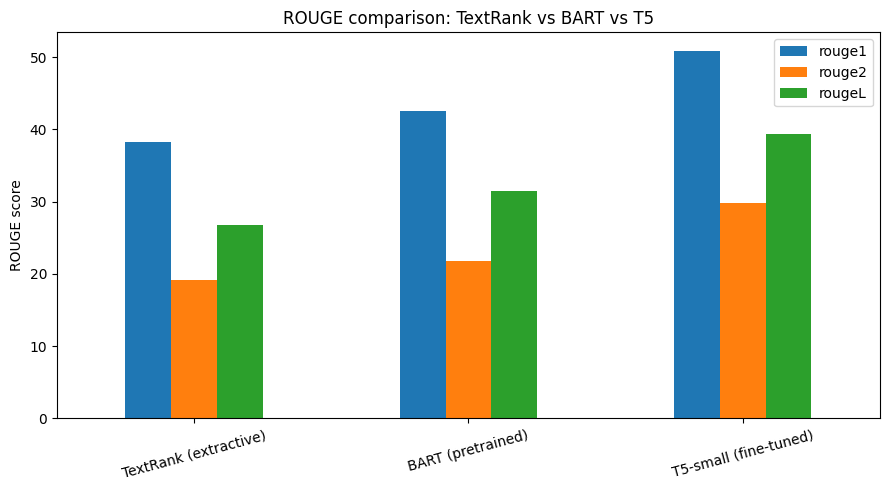

In [13]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results).T
display(results_df)
results_df.to_csv('results.csv')

results_df.plot(kind='bar', figsize=(9, 5))
plt.title('ROUGE comparison: TextRank vs BART vs T5')
plt.ylabel('ROUGE score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('rouge_comparison.png', dpi=150)
plt.show()

### Observations and limitations

- Compare the rows above: the abstractive models are expected to outperform the extractive baseline, and fine-tuning on in-domain data typically improves results further.
- The pretrained BART model was trained on CNN/DailyMail, which has longer summaries than this dataset. Part of the gap to the fine-tuned T5 is likely due to this domain and length mismatch, not only model quality.
- The test set contains only 100 articles and the results come from a single run, so small differences should not be over-interpreted.
- ROUGE measures word overlap and does not check factual consistency. Hallucination in the generated summaries was not evaluated.
- Possible future work: train on the full dataset, try larger models (`t5-base`, `bart-base`), and add BERTScore and a factuality check.

## 8. Demo app (Gradio)

A small web interface around the fine-tuned T5 model. Running the cell below creates a temporary public link where an article can be pasted to get its summary.

In [14]:
import gradio as gr

def summarize_demo(text):
    if not text or len(text.split()) < 30:
        return 'Please paste a news article with at least 30 words.'
    return t5_summarize([text], model, tok)[0]

demo = gr.Interface(
    fn=summarize_demo,
    inputs=gr.Textbox(lines=12, label='Paste a news article here'),
    outputs=gr.Textbox(label='Summary'),
    title='News Article Summarizer (fine-tuned T5)',
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://753122ecf39c20ddac.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 9. Save results

Download the results table and the comparison chart as files.

In [15]:
from google.colab import files
files.download('results.csv')
files.download('rouge_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Conclusion

This project compared an extractive baseline (TextRank), a pretrained abstractive model (BART) and a fine-tuned T5-small on a news summarization dataset.

- The fine-tuned T5-small achieved the highest scores on all three metrics (ROUGE-1 50.90, ROUGE-2 29.78, ROUGE-L 39.31), ahead of pretrained BART (42.62 / 21.76 / 31.53) and TextRank (38.32 / 19.21 / 26.78).
- On this dataset, fine-tuning a small model on in-domain data outperformed a larger pretrained model, partly because the pretrained model was trained on a different summary style.
- Results are based on a 100-article test set and a single run, so they are indicative rather than definitive.